# Formación IA · la empresa
### Notebook de prácticas - todos los ejemplos del programa

Este notebook ejecuta los scripts de cada bloque del programa.
El código fuente vive en los archivos `.py` de la carpeta `ejemplos_codigo/`.
Aquí los orquestamos y añadimos contexto entre cada práctica.

---
> **Versión:** ejecución local (VS Code + Jupyter)  
> **Cómo usarlo:**  
> 1. Abre este notebook desde la raíz del proyecto (donde está la carpeta `ejemplos_codigo/`).  
> 2. Ejecuta la celda de **Configuración** una sola vez para preparar el entorno.  
> 3. Luego ejecuta las celdas de cada bloque en orden, o salta a la sección que te interese.

## ⚙️ Configuración inicial
Ejecuta esta celda una sola vez al abrir el notebook.  
Requiere que VS Code abra este fichero desde la **raíz del proyecto** (donde está `ejemplos_codigo/`).

In [1]:
from pathlib import Path
import os

# ── Ruta a la carpeta de scripts ─────────────────────────────────
# VS Code Jupyter ejecuta las celdas con el directorio del notebook como CWD.
# 'ejemplos_codigo' debe estar en el mismo nivel que este fichero .ipynb.
SCRIPTS = Path('ejemplos_codigo')

if not SCRIPTS.is_dir():
    raise FileNotFoundError(
        f"No se encuentra '{SCRIPTS.resolve()}'.\n"
        "Asegúrate de abrir el notebook desde la raíz del proyecto."
    )

os.chdir(SCRIPTS)
print(f"✓ Directorio de trabajo: {os.getcwd()}")
print("Scripts disponibles:")
for f in sorted(Path('.').iterdir()):
    if f.suffix == '.py':
        print(f"  {f.name}")

# ── Dependencias ──────────────────────────────────────────────────
%pip install -q scikit-learn matplotlib numpy

# ── Gráficos inline ───────────────────────────────────────────────
%matplotlib inline

✓ Directorio de trabajo: d:\documentos_gdrive\proyectos_claude_mcp\projects\formación_AI_springter\ejemplos_codigo
Scripts disponibles:
  00_separabilidad_sql_vs_ml.py
  00b_resumir_rle_vs_semantica.py
  01_neurona_simple.py
  02_capa_densa.py
  03_activaciones_relu_softmax.py
  04_loss_crossentropy.py
  05_backpropagation.py
  06_optimizadores.py
  07_red_completa_entrenamiento.py
  08_ml_clasico_sklearn.py
Note: you may need to restart the kernel to use updated packages.


---
## Bloque 0 · Panorama general
### ¿Cuándo basta una regla y cuándo necesitas IA?

Estos dos ejemplos ilustran la diferencia entre problemas que se resuelven con lógica determinista
(una consulta SQL, un algoritmo clásico) y problemas donde la frontera es demasiado difusa
para cualquier regla explícita - ahí es donde entra el Machine Learning.


╔══════════════════════════════════════════════════════════════════╗
║   CLASIFICAR: ¿cuándo basta una regla y cuándo necesitas IA?    ║
╚══════════════════════════════════════════════════════════════════╝

Imagina que tienes que separar dos grupos de clientes.

CASO 1 -  Clientes premium vs. normales
  Los clientes premium gastan más de 10.000 € al año y hacen más
  de 5 pedidos. Cualquier analista puede escribir esto en SQL:

      SELECT * FROM clientes
      WHERE importe_anual > 10000
        AND num_pedidos   > 5

  Una sola condición. Una línea recta en el espacio de datos.
  No necesitas Machine Learning. No necesitas IA.

CASO 2 -  Clientes que van a cancelar vs. los que no
  Tienes frecuencia de login y puntuación NPS de cada cliente.
  ¿Puedes escribir un WHERE que detecte el churn?

      SELECT * FROM clientes
      WHERE sesiones_mes < ???
        AND nps           < ???

  Los signos de interrogación no son pereza: es que NO EXISTE
  ningún umbral simple. Los clientes q

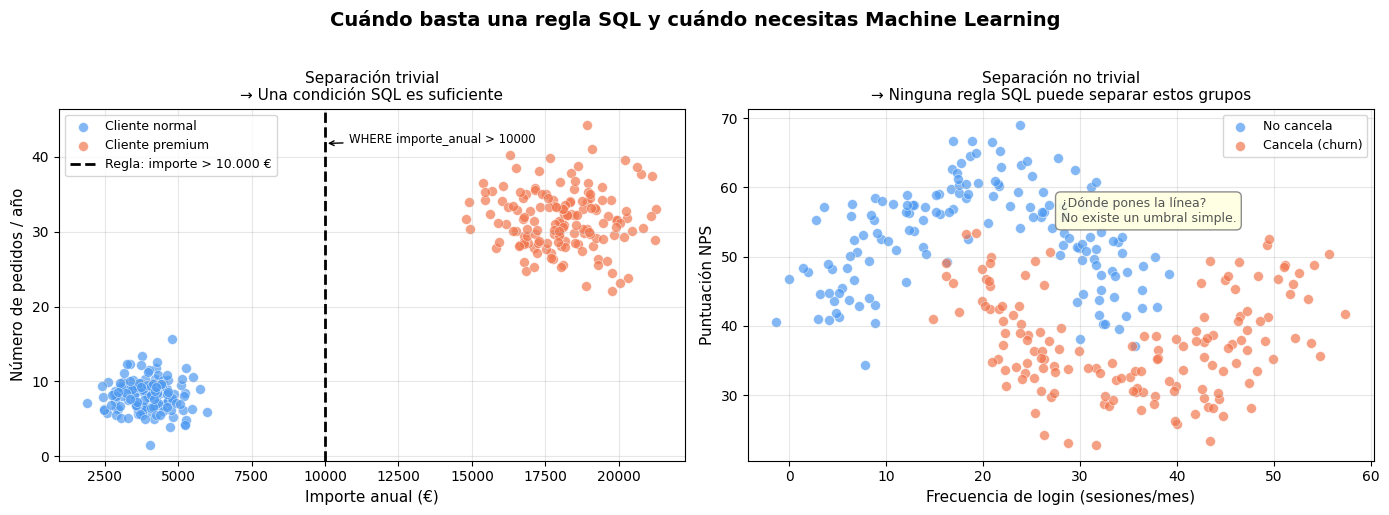


--- Reflexión ---
Panel izquierdo: una sola condición (importe > 10.000 €) separa
perfectamente los grupos. Cualquier analista puede escribir ese WHERE.

Panel derecho: los clientes que cancelan y los que no se MEZCLAN
en el espacio de datos. No existe ningún umbral simple de login o NPS
que los separe. Aquí es donde un modelo de ML aprende la frontera.


<Figure size 640x480 with 0 Axes>

In [2]:
# CLASIFICAR: separación trivial (SQL) vs separación no trivial (ML)
# ─────────────────────────────────────────────────────────────────
# Compara dos nubes de puntos 2D:
#   · Izquierda: dos grupos perfectamente separables con un umbral numérico.
#   · Derecha  : dos grupos entrelazados (dos lunas) donde ningún WHERE funciona.
%run 00_separabilidad_sql_vs_ml.py


╔══════════════════════════════════════════════════════════════════╗
║        RESUMIR: ¿cuándo basta un algoritmo y cuándo no?         ║
╚══════════════════════════════════════════════════════════════════╝

"Resumir" no siempre significa lo mismo. Hay dos mundos muy distintos.

MUNDO 1 -  Resumir datos binarios (señal de un sensor de inventario)
  Una secuencia de 0s y 1s tiene una estructura matemática pura:
  símbolos repetidos consecutivamente. Un algoritmo de 10 líneas,
  el Run-Length Encoding (RLE), los agrupa y produce un resumen
  compacto que además es REVERSIBLE: puedes recuperar los datos
  originales sin perder un solo bit.

  No hay interpretación. No hay ambigüedad. No hay IA.

MUNDO 2 -  Resumir un email de soporte de un cliente
  El email tiene 80 palabras. Pero ¿cuáles importan? ¿Las más
  frecuentes? ¿Las primeras? ¿La primera y la última frase?

  Ningún algoritmo clásico sabe que...
    → "almacén bloqueado" es más urgente que "buenos días"
    → "REF-4521" es la r

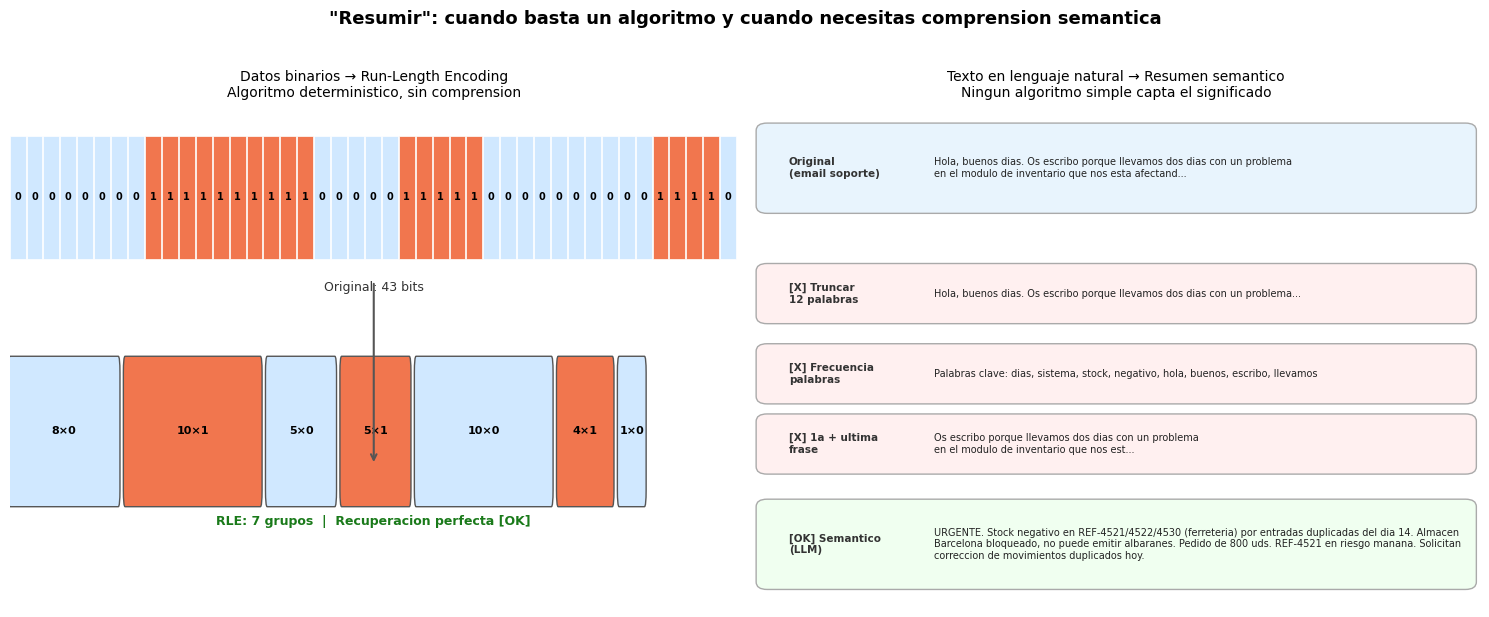



--- Conclusion ---
RLE: el algoritmo SABE que hacer con cada bit. La regla es trivial.
Texto: no existe ningun algoritmo que sepa que parte es 'urgente',
que referencias son criticas, o que el bloqueo del almacen es lo mas
importante. Eso requiere comprension semantica, que es lo que aporta un LLM.


<Figure size 640x480 with 0 Axes>

In [3]:
# RESUMIR: Run-Length Encoding (RLE) vs resumen semántico con LLM
# ───────────────────────────────────────────────────────────────
# Demuestra que "resumir" datos binarios es matemática pura (RLE lo resuelve
# perfectamente), mientras que resumir texto requiere comprensión semántica.
# Los tres intentos algorítmicos (truncar, frecuencia, 1ª+última frase) fallan.
%run 00b_resumir_rle_vs_semantica.py

---
## Bloque 1 · Machine Learning y Redes Neuronales desde Cero

Construcción paso a paso de una red neuronal completa, siguiendo la
estructura del libro *Neural Networks from Scratch* de Harrison Kinsley,
adaptada al contexto de la empresa.

In [4]:
# 1.3 · La neurona como unidad de cómputo
# ────────────────────────────────────────
# Implementa una neurona desde cero: producto escalar de entradas y pesos,
# suma del sesgo, y ventaja de NumPy sobre bucles Python.
%run 01_neurona_simple.py

=== Neurona simple (Python puro) ===
Inputs:  [1.0, 2.0, 3.0]
Weights: [0.2, 0.8, -0.5]
Bias:    2.0
Output:  2.3

=== Neurona con bucle (4 inputs) ===
Output: 4.8

=== Neurona con NumPy (np.dot) ===
Output: 4.8

=== Capa de 3 neuronas ===
Output de la capa: [4.8   1.21  2.385]

=== Batch de 3 muestras, capa de 3 neuronas ===
Shape del output: (3, 3)
Output:
[[ 4.8    1.21   2.385]
 [ 8.9   -1.81   0.2  ]
 [ 1.41   1.051  0.026]]


In [5]:
# 1.4 · Capas densas y operaciones matriciales
# ─────────────────────────────────────────────
# Clase Layer_Dense: forward pass sobre un batch de muestras.
# Inicialización de pesos (ruptura de simetría) y sesgos.
%run 02_capa_densa.py

Shape de X: (300, 2)
Shape de y: (300,)
Clases: [0 1 2]

Shape del output de la capa: (300, 3)
Primeras 5 salidas:
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-1.04751877e-04  1.13953608e-04 -4.79835027e-05]
 [-2.74148425e-04  3.17291492e-04 -8.69217965e-05]
 [-4.21883664e-04  5.26662557e-04 -5.59126778e-05]
 [-5.77076817e-04  7.14014087e-04 -8.94304470e-05]]

Shape del output de la segunda capa: (300, 3)
Primeras 5 salidas de la segunda capa:
[[0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.75651160e-06 1.60895890e-06 6.86066362e-07]
 [4.13099288e-06 3.90289939e-06 1.85216568e-06]
 [5.41864346e-06 5.38596661e-06 2.96435410e-06]
 [7.56804485e-06 7.47039493e-06 4.03583830e-06]]


In [6]:
# 1.5 · Funciones de activación: ReLU y Softmax
# ───────────────────────────────────────────────
# Por qué la no-linealidad es imprescindible. ReLU para capas ocultas,
# Softmax para clasificación multiclase. Truco de estabilidad numérica.
%run 03_activaciones_relu_softmax.py

=== Demostracion de ReLU ===
Input:
[[-1.   2.  -0.5  3.3]
 [ 0.  -2.7  1.1  2.2]]
Output ReLU:
[[0.  2.  0.  3.3]
 [0.  0.  1.1 2.2]]

=== Demostracion de Softmax ===
Input:
[[ 4.8    1.21   2.385]
 [ 8.9   -1.81   0.2  ]
 [ 1.41   1.051  0.026]]
Output Softmax (probabilidades):
[[8.95282664e-01 2.47083068e-02 8.00090293e-02]
 [9.99811129e-01 2.23163963e-05 1.66554348e-04]
 [5.13097164e-01 3.58333899e-01 1.28568936e-01]]
Suma por muestra: [1. 1. 1.]

=== Pipeline: Dense -> ReLU -> Dense -> Softmax ===
Predicciones (primeras 5 muestras):
[[0.33333333 0.33333333 0.33333333]
 [0.33333317 0.33333318 0.33333364]
 [0.33333289 0.33333292 0.3333342 ]
 [0.33333259 0.33333264 0.33333477]
 [0.33333233 0.33333239 0.33333528]]
Clases predichas: [0 2 2 2 2]
Clases reales:    [0 0 0 0 0]


In [7]:
# 1.6 · Función de pérdida: Categorical Cross-Entropy
# ─────────────────────────────────────────────────────
# Cálculo del error. Diferencia entre accuracy y loss.
# Clipping para evitar log(0). Soporte para etiquetas densas y one-hot.
%run 04_loss_crossentropy.py

=== Categorical Cross-Entropy Loss ===
Predicciones:
[[0.7  0.1  0.2 ]
 [0.1  0.5  0.4 ]
 [0.02 0.9  0.08]]
Etiquetas reales: [0 1 1]
Loss: 0.38506
Accuracy: 100.00%

=== Efecto de -log en la confianza ===
  Confianza 0.99 -> Loss: 0.0101
  Confianza 0.90 -> Loss: 0.1054
  Confianza 0.70 -> Loss: 0.3567
  Confianza 0.50 -> Loss: 0.6931
  Confianza 0.30 -> Loss: 1.2040
  Confianza 0.10 -> Loss: 2.3026
  Confianza 0.01 -> Loss: 4.6052

=== Con etiquetas one-hot ===
Loss (one-hot, target clase 2 en muestra 3): 1.19185


In [8]:
# 1.7 · Backpropagation
# ──────────────────────
# Regla de la cadena aplicada capa a capa. Gradientes de pesos, sesgos
# y entradas. Simplificación elegante de Softmax + Cross-Entropy combinados.
%run 05_backpropagation.py

=== la empresa Pass ===
Loss: 1.09859
Accuracy: 36.00%

=== Backward Pass (gradientes calculados) ===
Gradientes de dense1.weights: shape (2, 64), media -0.000005
Gradientes de dense1.biases:  shape (1, 64), media -0.000054
Gradientes de dense2.weights: shape (64, 3), media 0.000000
Gradientes de dense2.biases:  shape (1, 3), media -0.000000


In [9]:
# 1.8 · Optimizadores: SGD, AdaGrad, RMSProp y Adam
# ────────────────────────────────────────────────────
# Cómo los gradientes se convierten en actualizaciones de parámetros.
# Momentum, learning rate adaptativo y corrección de sesgo (bias correction).
%run 06_optimizadores.py

=== Entrenamiento con Adam ===
Epoch     0 | Loss: 1.09859 | Acc: 0.3600 | LR: 0.020000
Epoch  1000 | Loss: 0.24326 | Acc: 0.9067 | LR: 0.019990
Epoch  2000 | Loss: 0.15828 | Acc: 0.9367 | LR: 0.019980
Epoch  3000 | Loss: 0.13213 | Acc: 0.9500 | LR: 0.019970
Epoch  4000 | Loss: 0.11747 | Acc: 0.9567 | LR: 0.019960
Epoch  5000 | Loss: 0.11016 | Acc: 0.9533 | LR: 0.019950
Epoch  6000 | Loss: 0.10054 | Acc: 0.9700 | LR: 0.019940
Epoch  7000 | Loss: 0.09609 | Acc: 0.9700 | LR: 0.019930
Epoch  8000 | Loss: 0.09227 | Acc: 0.9700 | LR: 0.019920
Epoch  9000 | Loss: 0.08996 | Acc: 0.9700 | LR: 0.019910
Epoch 10000 | Loss: 0.08880 | Acc: 0.9667 | LR: 0.019901


In [10]:
# 1.9 · Red completa con regularización y dropout
# ─────────────────────────────────────────────────
# Pipeline de entrenamiento end-to-end: forward, loss, backward, optimizer.
# L1/L2 regularization, dropout con escalado invertido, validación out-of-sample.
%run 07_red_completa_entrenamiento.py

=== Entrenamiento: Red completa con Dropout y Regularizacion L2 ===

Epoch     0 | Loss: 1.09861 (data: 1.09861, reg: 0.00001) | Acc: 0.3367 | LR: 0.050000
Epoch  1000 | Loss: 0.76457 (data: 0.71607, reg: 0.04850) | Acc: 0.6733 | LR: 0.047621
Epoch  2000 | Loss: 0.71678 (data: 0.66554, reg: 0.05124) | Acc: 0.7000 | LR: 0.045457
Epoch  3000 | Loss: 0.75033 (data: 0.69912, reg: 0.05121) | Acc: 0.7333 | LR: 0.043480
Epoch  4000 | Loss: 0.75890 (data: 0.71068, reg: 0.04823) | Acc: 0.7067 | LR: 0.041668
Epoch  5000 | Loss: 0.70144 (data: 0.65343, reg: 0.04802) | Acc: 0.7333 | LR: 0.040002
Epoch  6000 | Loss: 0.58470 (data: 0.53828, reg: 0.04642) | Acc: 0.7733 | LR: 0.038463
Epoch  7000 | Loss: 0.67089 (data: 0.62446, reg: 0.04643) | Acc: 0.7567 | LR: 0.037038
Epoch  8000 | Loss: 0.67336 (data: 0.62676, reg: 0.04659) | Acc: 0.7733 | LR: 0.035716
Epoch  9000 | Loss: 0.70542 (data: 0.65900, reg: 0.04641) | Acc: 0.7400 | LR: 0.034484
Epoch 10000 | Loss: 0.67588 (data: 0.62960, reg: 0.04629) | A

In [11]:
# 1.2 · Algoritmos clásicos con Scikit-Learn
# ────────────────────────────────────────────
# Regresión lineal, KNN, SVM con kernel RBF y K-Means clustering.
# Cuándo usar ML clásico en lugar de redes neuronales (datos tabulares, 
# volumen moderado, necesidad de interpretabilidad).
%run 08_ml_clasico_sklearn.py

1. REGRESION LINEAL
Coeficientes (pesos): [71.88644879 22.54243658 72.4845378 ]
Intercepto (sesgo):   -0.6364
R2 Score:             0.9850
MSE:                  132.6237

2. K-NEAREST NEIGHBORS (KNN)
K=3: Accuracy = 0.8333
K=5: Accuracy = 0.8167
K=7: Accuracy = 0.8167

3. SUPPORT VECTOR MACHINES (SVM)
Kernel 'linear': Accuracy = 0.8667
Kernel 'rbf': Accuracy = 0.8667
Kernel 'poly': Accuracy = 0.8333

4. K-MEANS CLUSTERING (no supervisado)
Centroides:
[[-2.60516878  8.99280115]
 [-6.85126211 -6.85031833]
 [ 4.68687447  2.01434593]
 [-8.83456141  7.24430734]]
Inercia (suma de distancias al centroide): 203.89
Labels asignados (primeros 20): [3 3 0 1 3 1 2 1 0 2 0 2 0 0 3 0 3 2 0 0]

Metodo del codo:
  K=2: Inercia = 9051.82
  K=3: Inercia = 1773.74
  K=4: Inercia = 203.89
  K=5: Inercia = 184.41
  K=6: Inercia = 165.72
  K=7: Inercia = 148.07



---
## 🧪 Sandbox: experimentos libres

Usa estas celdas para modificar parámetros de los ejemplos anteriores
y observar cómo cambia el comportamiento del modelo.

**Ideas para experimentar:**
- En `01_neurona_simple.py`: cambia los pesos y observa el cambio en la salida.
- En `03_activaciones_relu_softmax.py`: prueba con entradas negativas muy grandes.
- En `06_optimizadores.py`: compara el número de épocas para converger con SGD vs Adam.
- En `07_red_completa_entrenamiento.py`: sube la tasa de dropout a 0.5 y observa el efecto.

In [12]:
# Escribe aquí tu código de experimento
